# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Set plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load Datasets 

In [2]:
print("Loading Datasets")

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

print("Fake Dataset Shape :", fake.shape)
print("True Dataset Shape :", true.shape)

Loading Datasets
Fake Dataset Shape : (23481, 4)
True Dataset Shape : (21417, 4)


# Add Labels

In [4]:
fake["label"] = 0   # Fake News
true["label"] = 1   # True News

# Combine Datasets 

In [5]:
data = pd.concat([fake, true], ignore_index=True)

# Shuffle dataset
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nCombined Dataset shape :", data.shape)
print("\nColumns in Dataset :")
print(data.columns)


Combined Dataset shape : (44898, 5)

Columns in Dataset :
Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')


# Basic Data Inspection

In [8]:
print("\nFirst 5 Rows :")
print(data.head())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nLabel Distribution :")
print(data["label"].value_counts())


First 5 Rows :
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  
3         May 22, 2017      0  
4       June 24, 2016       1  

Missing Values:
title      0
text

# Data Cleaning ( Handling Missing Values )

In [9]:
for col in ["title", "text", "subject"]:
    if col in data.columns:
        data[col] = data[col].fillna("")

# Exploratory Data Analysis ( EDA )

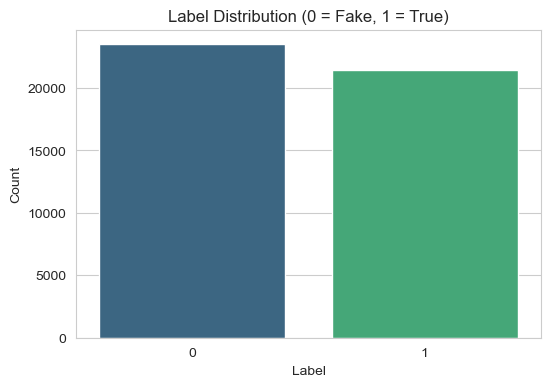

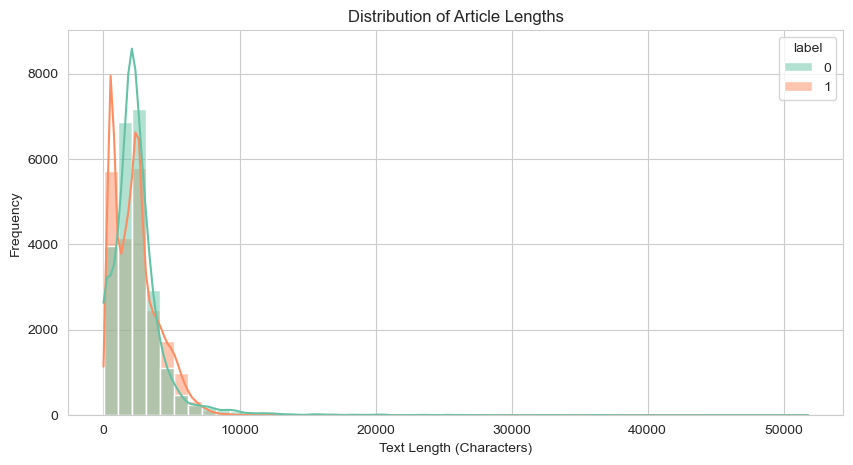


Average Text Length by Label :
Fake News (0) : 2547.4
True News (1) : 2383.28


In [11]:
#Label Distribution Plot
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=data, hue="label", palette="viridis", legend=False)
plt.title("Label Distribution (0 = Fake, 1 = True)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

#Article Length Analysis
data["text_length"] = data["text"].apply(len)
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x="text_length", hue="label", bins=50, kde=True, palette="Set2")
plt.title("Distribution of Article Lengths")
plt.xlabel("Text Length (Characters)")
plt.ylabel("Frequency")
plt.show()

#Average Article Length by Class
avg_lengths = data.groupby("label")["text_length"].mean()
print("\nAverage Text Length by Label :")
print("Fake News (0) :", round(avg_lengths[0], 2))
print("True News (1) :", round(avg_lengths[1], 2))

# Text Processing Function 

In [12]:
def clean_text(text):

    text = text.lower()
    text = re.sub(r"http\\S+|www\\S+|https\\S+", "", text)  # Remove URLs
    text = re.sub(r"\\d+", "", text)  # Remove Numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # Remove Punctuation
    text = re.sub(r"\\s+", " ", text).strip()  # Remove Extra Spaces
    return text

print("\nCleaning Text Data")
data["clean_text"] = data["text"].apply(clean_text)


Cleaning Text Data


# Word Clouds 

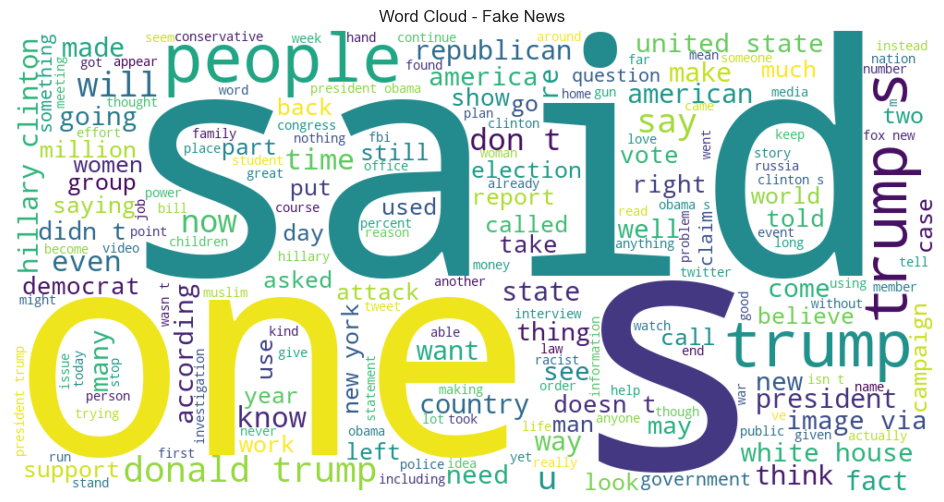

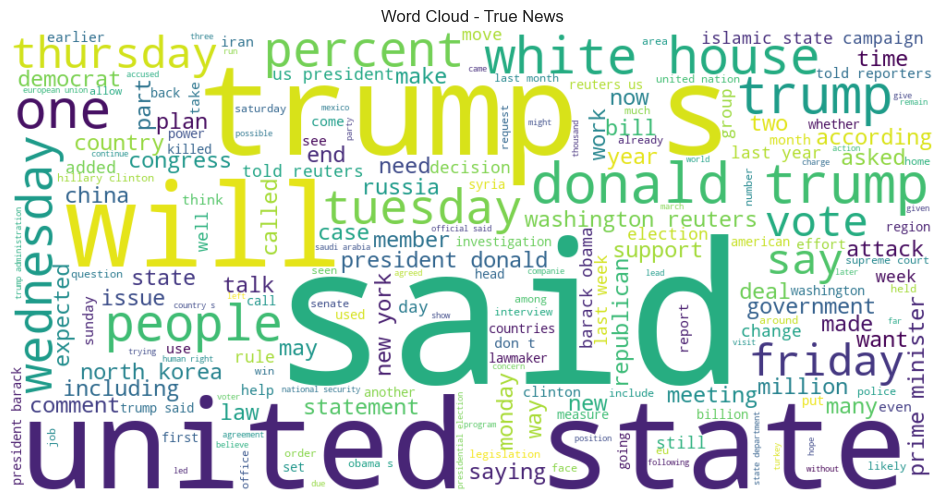

In [13]:
fake_words = " ".join(data[data["label"] == 0]["clean_text"].astype(str).tolist())
true_words = " ".join(data[data["label"] == 1]["clean_text"].astype(str).tolist())

# Fake News Word Cloud
plt.figure(figsize=(12, 6))
fake_wc = WordCloud(width=1000, height=500, background_color="white").generate(fake_words)
plt.imshow(fake_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Fake News")
plt.show()

# True News Word Cloud
plt.figure(figsize=(12, 6))
true_wc = WordCloud(width=1000, height=500, background_color="white").generate(true_words)
plt.imshow(true_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - True News")
plt.show()

# Features and Targets 

In [34]:
data["combined_text"] = data["title"].fillna("") + " " + data["text"].fillna("")
data["combined_text"] = data["combined_text"].apply(clean_text)

X = data["combined_text"]
y = data["label"]

# Train Test Split

In [35]:
x_train, x_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

print("\nTrain Size :", x_train.shape[0])
print("Test Size :", x_test.shape[0])


Train Size : 35918
Test Size : 8980


# TF-IDF Vectorization 

In [39]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.8,
    min_df=3,
    ngram_range=(1, 2),   
    sublinear_tf=True,
    max_features=50000
)

xv_train = vectorizer.fit_transform(x_train)
xv_test = vectorizer.transform(x_test)

print("\nTF-IDF Train Shape :", xv_train.shape)
print("\nTF-IDF Test Shape  :", xv_test.shape)


TF-IDF Train Shape : (35918, 50000)

TF-IDF Test Shape  : (8980, 50000)


# Model Training 

In [37]:
from sklearn.linear_model import PassiveAggressiveClassifier

print("\nTraining PassiveAggressiveClassifier")

model = PassiveAggressiveClassifier(max_iter=1000, random_state=42)
model.fit(xv_train, y_train)


Training PassiveAggressiveClassifier


PassiveAggressiveClassifier(random_state=42)

# Prediction and Evaluation 

In [41]:
# Prediction
y_pred = model.predict(xv_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report :\n")
print(classification_report(y_test, y_pred))


Model Accuracy: 99.71%

Classification Report :

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



# Confusion Matrix 

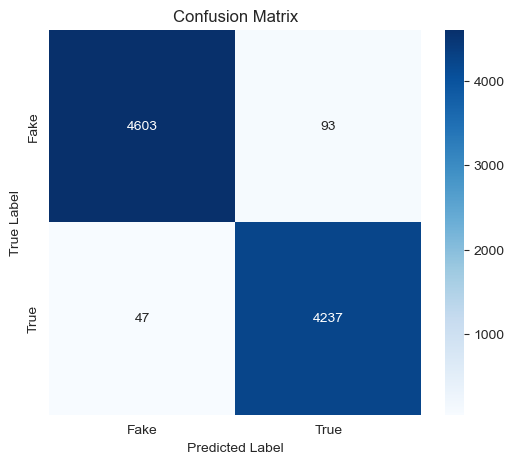

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Custom Prediction Function 

In [42]:
def predict_news(news_text):
    
    # Predict whether a given news article is Fake or True.
   
    cleaned = clean_text(news_text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]

    if prediction == 0:
        return "Fake News"
    else:
        return "True News"

# Example Prediction 

In [45]:
true_sample = data[data["label"] == 1]["combined_text"].iloc[0]

print("ACTUAL NEWS SAMPLE :\n")
print(true_sample[:400], "...")

print("\nPrediction :", predict_news(true_sample))

ACTUAL NEWS SAMPLE :

trump drops steve bannon from national security council washington reuters  us president donald trump removed his chief strategist steve bannon from the national security council on wednesday reversing his controversial decision early this year to give a political adviser an unprecedented role in security discussions trump’s overhaul of the nsc confirmed by a white house official also elevated gen ...

Prediction : True News


In [ ]:
fake_sample = data[data["label"] == 0]["combined_text"].iloc[0]

print("ACTUAL NEWS SAMPLE :\n")
print(fake_sample[:400], "...")

print("\nPrediction :", predict_news(fake_sample))